# imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import lightgbm as lgb
import holidays
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("../other_data/hotel_bookings.csv")

In [4]:
# Build arrival date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

In [5]:
# Only Considering the Resort
df = df[df.hotel == 'Resort Hotel']
agg_df = df.groupby('arrival_date', as_index=False).agg(
    total_bookings=('is_canceled', 'count'), # Total demand per day 
    avg_prev_cancellations=('previous_cancellations', 'mean'),
    avg_prev_non_cancellations=('previous_bookings_not_canceled', 'mean'))
# agg_df.index = agg_df['arrival_date']
agg_df.index.name = 'date'
agg_df['arrival_date'] = pd.to_datetime(agg_df['arrival_date'])


In [6]:
def add_lag_features(df, lags=[1, 7, 14]):
    df = df.sort_values(['arrival_date'])
    for lag in lags:
        df[f'lag_{lag}'] = df['total_bookings'].shift(lag)
    return df

def add_time_and_holiday_features(df, country='IN'):
    df['dayofweek'] = df['arrival_date'].dt.dayofweek
    df['month'] = df['arrival_date'].dt.month
    df['quarter'] = df['arrival_date'].dt.quarter
    df['year'] = df['arrival_date'].dt.year
    df['dayofyear'] = df['arrival_date'].dt.dayofyear
    df['weekofyear'] = df['arrival_date'].dt.isocalendar().week
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    # Holiday indicator
    ind_holidays = holidays.India()
    df['is_holiday'] = df['arrival_date'].isin(ind_holidays).astype(int)
    return df
def add_rolling_features(df):
  df['rolling_mean_7'] = df['total_bookings'].rolling(window=7).mean()
  df['rolling_std_7'] = df['total_bookings'].rolling(window=7).std()
  return df
# Step-by-step
agg_df = add_lag_features(agg_df, lags=[1, 7, 14])
agg_df = add_time_and_holiday_features(agg_df)
agg_df = add_rolling_features(agg_df)
# Drop nulls from lags
agg_df = agg_df.dropna()

In [7]:
# Predicting total_bookings
agg_df = agg_df.sort_values('arrival_date')
X = agg_df.drop(columns=['total_bookings', 'arrival_date'])
y = agg_df['total_bookings']


In [9]:
# Time-based split
split_date = agg_df['arrival_date'].quantile(0.8)
X_train = X[agg_df['arrival_date'] <= split_date]
X_test = X[agg_df['arrival_date'] > split_date]
y_train = y[agg_df['arrival_date'] <= split_date]
y_test = y[agg_df['arrival_date'] > split_date]

In [10]:
model = lgb.LGBMRegressor(
    objective='regression',
    metric='mape',
    learning_rate=0.05,
    num_leaves=15,
    max_depth=15,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_estimators=500
)

In [11]:
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)])

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train set: 623, number of used features: 14
[LightGBM] [War

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,15
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred) * 100)

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
MAE: 12.942277265307016
MAPE: 24.215928515248848


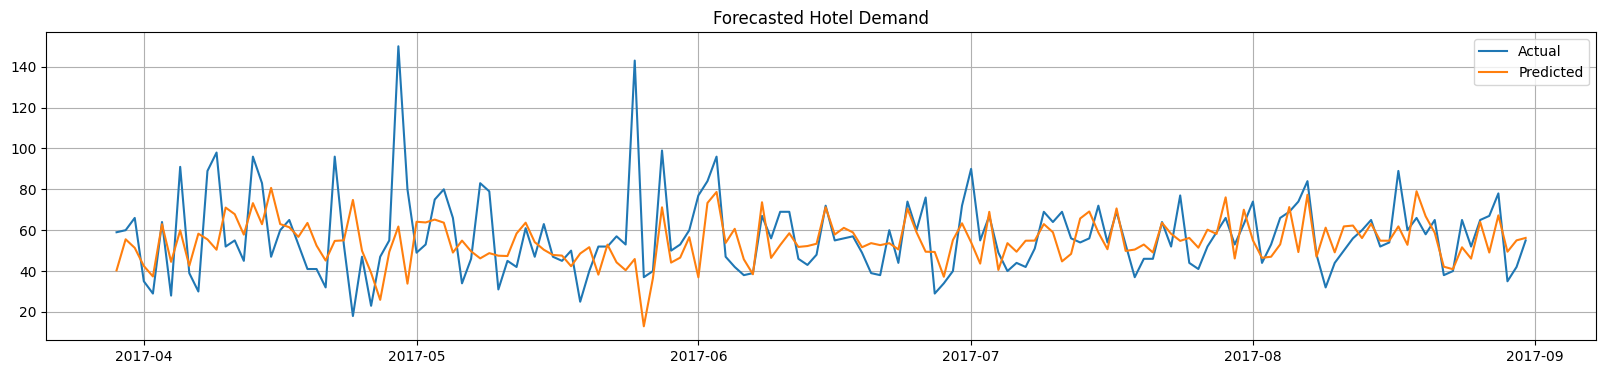

In [13]:
# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.plot(agg_df['arrival_date'][y_test.index], y_test, label='Actual')
plt.plot(agg_df['arrival_date'][y_test.index], y_pred, label='Predicted')
plt.title("Forecasted Hotel Demand")
plt.legend()
plt.grid(True)
plt.show()